# Comparação de modelos de predição

Notebook didático para os dois problemas de classificação. As etapas mostram a leitura dos dados, separação entre treino e teste, treinamento, predição e avaliação.

## Etapa 1 — Importar as bibliotecas

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## Etapa 2 — Definir as configurações

A semente fixa torna o experimento reproduzível. Serão usados 70% dos dados para treino e 30% para teste.

In [5]:
SEMENTE_ALEATORIA = 42
PROPORCAO_TESTE = 0.30
QUANTIDADE_PARTES_CV = 5

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

## Etapa 3 — Localizar e carregar as bases

As duas bases CSV acompanham este notebook na mesma pasta. Não é necessário clonar o repositório original nem acessar a internet.

In [6]:
def localizar_pasta_dos_dados() -> Path:
    """Localiza as bases que acompanham este notebook."""

    pastas_candidatas = [
        Path.cwd(),
        Path.cwd() / "exercicios_predicao",
    ]

    for pasta in pastas_candidatas:
        if (pasta / "dados_predicao_modelos.csv").exists():
            return pasta

    raise FileNotFoundError(
        "As bases CSV não foram encontradas junto ao notebook."
    )


PASTA_DOS_DADOS = localizar_pasta_dos_dados()

dados_compra = pd.read_csv(
    PASTA_DOS_DADOS / "dados_predicao_modelos.csv"
)
dados_saude = pd.read_csv(
    PASTA_DOS_DADOS / "dados_saude_predicao.csv"
)

print(f"Problema 1: {dados_compra.shape[0]} linhas")
print(f"Problema 2: {dados_saude.shape[0]} linhas")

Problema 1: 250 linhas
Problema 2: 250 linhas


## Etapa 4 — Conferir os dados

Antes de treinar, verificamos exemplos, tipos, valores ausentes e equilíbrio das classes.

In [7]:
def conferir_dados(
    dados: pd.DataFrame,
    coluna_alvo: str,
) -> None:
    """Apresenta as verificações realizadas antes do treino."""

    print("Primeiras linhas:")
    display(dados.head())

    print("Valores ausentes por coluna:")
    display(
        dados.isna().sum().to_frame(name="Ausentes")
    )

    print("Distribuição da variável alvo:")
    display(
        dados[coluna_alvo]
        .value_counts()
        .sort_index()
        .to_frame(name="Quantidade")
    )

## Etapa 5 — Criar os modelos

São os mesmos sete classificadores dos exemplos. Regressão Logística, KNN e SVM usam padronização dentro de um pipeline, ajustada somente no treino.

In [8]:
def criar_modelos() -> dict:
    """Cria os classificadores utilizados na comparação."""

    return {
        "Regressão Logística": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2_000,
                random_state=SEMENTE_ALEATORIA,
            ),
        ),
        "Árvore de Decisão": DecisionTreeClassifier(
            random_state=SEMENTE_ALEATORIA
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=SEMENTE_ALEATORIA,
        ),
        "KNN": make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(),
        ),
        "Naive Bayes": GaussianNB(),
        "SVM": make_pipeline(
            StandardScaler(),
            SVC(),
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=SEMENTE_ALEATORIA
        ),
    }

## Etapa 6 — Separar, treinar e avaliar

`X` contém as variáveis de entrada e `y` contém a resposta correta. O conjunto de teste fica separado e não participa do treinamento. O F1 Macro segue o padrão dos exemplos e atribui a mesma importância às classes 0 e 1.

In [9]:
def avaliar_modelos(
    dados: pd.DataFrame,
    coluna_alvo: str,
) -> tuple[pd.DataFrame, dict, dict]:
    """Treina, testa e avalia todos os modelos."""

    # X: características usadas para realizar a predição.
    X = dados.drop(columns=coluna_alvo)

    # y: classe correta que o modelo precisa aprender.
    y = dados[coluna_alvo]

    # 70% para treino e 30% para teste.
    # stratify preserva a proporção das classes.
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X,
        y,
        test_size=PROPORCAO_TESTE,
        random_state=SEMENTE_ALEATORIA,
        stratify=y,
    )

    print(f"Registros de treino: {len(X_treino)}")
    print(f"Registros de teste: {len(X_teste)}")

    validacao_cruzada = StratifiedKFold(
        n_splits=QUANTIDADE_PARTES_CV,
        shuffle=True,
        random_state=SEMENTE_ALEATORIA,
    )

    resultados = []
    matrizes = {}
    relatorios = {}

    for nome, modelo_base in criar_modelos().items():
        modelo = clone(modelo_base)

        # TREINAMENTO: o modelo aprende apenas com X_treino e y_treino.
        modelo.fit(X_treino, y_treino)

        # Predição do treino: ajuda a identificar overfitting.
        previsao_treino = modelo.predict(X_treino)

        # Predição do teste: mede o desempenho em dados não vistos.
        previsao_teste = modelo.predict(X_teste)

        acuracia_treino = accuracy_score(
            y_treino,
            previsao_treino,
        )
        acuracia_teste = accuracy_score(
            y_teste,
            previsao_teste,
        )
        f1_treino = f1_score(
            y_treino,
            previsao_treino,
            average="macro",
            zero_division=0,
        )
        f1_teste = f1_score(
            y_teste,
            previsao_teste,
            average="macro",
            zero_division=0,
        )

        # Repete a avaliação em cinco divisões estratificadas.
        metricas_cv = cross_validate(
            clone(modelo_base),
            X,
            y,
            cv=validacao_cruzada,
            scoring={
                "acuracia": "accuracy",
                "f1_macro": "f1_macro",
            },
        )

        matriz = confusion_matrix(
            y_teste,
            previsao_teste,
            labels=[0, 1],
        )

        matrizes[nome] = matriz
        relatorios[nome] = classification_report(
            y_teste,
            previsao_teste,
            zero_division=0,
        )

        resultados.append(
            {
                "Modelo": nome,
                "Acurácia treino": acuracia_treino,
                "Acurácia teste": acuracia_teste,
                "F1 Macro treino": f1_treino,
                "F1 Macro teste": f1_teste,
                "F1 Macro CV médio": (
                    metricas_cv["test_f1_macro"].mean()
                ),
                "F1 Macro CV desvio": (
                    metricas_cv["test_f1_macro"].std()
                ),
                "Gap F1 treino-teste": f1_treino - f1_teste,
                "VN": matriz[0, 0],
                "FP": matriz[0, 1],
                "FN": matriz[1, 0],
                "VP": matriz[1, 1],
            }
        )

    tabela = pd.DataFrame(resultados)
    tabela = tabela.sort_values(
        by="F1 Macro CV médio",
        ascending=False,
    ).reset_index(drop=True)

    return tabela, matrizes, relatorios

## Etapa 7 — Apresentar relatórios e gráficos

In [10]:
def mostrar_relatorios(relatorios: dict) -> None:
    """Exibe precisão, recall e F1 por classe."""

    for nome, relatorio in relatorios.items():
        print(f"MODELO: {nome}")
        print(relatorio)
        print("-" * 60)


def mostrar_grafico(titulo: str, metricas: pd.DataFrame) -> None:
    """Compara as principais métricas dos modelos."""

    dados_ordenados = metricas.sort_values(
        by="F1 Macro CV médio"
    )
    colunas = [
        "Acurácia teste",
        "F1 Macro teste",
        "F1 Macro CV médio",
    ]

    eixo = dados_ordenados.plot.barh(
        x="Modelo",
        y=colunas,
        figsize=(11, 6),
        xlim=(0, 1),
    )
    eixo.set_title(titulo)
    eixo.set_xlabel("Pontuação")
    eixo.set_ylabel("")
    eixo.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def mostrar_matrizes(titulo: str, matrizes: dict) -> None:
    """Exibe as matrizes de confusão dos sete modelos."""

    figura, eixos = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(14, 9),
    )

    for eixo, (nome, matriz) in zip(
        eixos.flat,
        matrizes.items(),
    ):
        ConfusionMatrixDisplay(
            confusion_matrix=matriz,
            display_labels=[0, 1],
        ).plot(
            ax=eixo,
            cmap="Blues",
            colorbar=False,
        )
        eixo.set_title(nome)

    for eixo_vazio in eixos.flat[len(matrizes):]:
        eixo_vazio.axis("off")

    figura.suptitle(titulo)
    figura.tight_layout(
        rect=[0, 0, 1, 0.96],
        h_pad=3,
        w_pad=2,
    )
    plt.show()

# Problema 1 — Compra de produto

In [11]:
conferir_dados(dados_compra, "Compro_Produto")

Primeiras linhas:


,Idade,Renda_Anual_K,Score_Credito,Pontuacao_Engajamento,Compro_Produto
0,56,141.8,534,7.1,0
1,46,37.9,308,8.1,0
2,32,64.3,373,5.5,0
3,60,34.8,791,1.8,0
4,25,140.2,552,5.8,0


Valores ausentes por coluna:


,Ausentes
Idade,0
Renda_Anual_K,0
Score_Credito,0
Pontuacao_Engajamento,0
Compro_Produto,0


Distribuição da variável alvo:


,Quantidade
Compro_Produto,
0,151
1,99


In [12]:
(
    metricas_compra,
    matrizes_compra,
    relatorios_compra,
) = avaliar_modelos(
    dados=dados_compra,
    coluna_alvo="Compro_Produto",
)

display(metricas_compra.round(3))

Registros de treino: 175
Registros de teste: 75


,Modelo,Acurácia treino,Acurácia teste,F1 Macro treino,F1 Macro teste,F1 Macro CV médio,F1 Macro CV desvio,Gap F1 treino-teste,VN,FP,FN,VP
0,SVM,0.777,0.680,0.745,0.624,0.678,0.060,0.121,40,5,19,11
1,Naive Bayes,0.720,0.653,0.695,0.610,0.662,0.051,0.085,37,8,18,12
2,Regressão Logística,0.709,0.653,0.680,0.610,0.661,0.073,0.070,37,8,18,12
3,Random Forest,1.000,0.653,1.000,0.610,0.657,0.063,0.390,37,8,18,12
4,KNN,0.777,0.653,0.761,0.624,0.646,0.052,0.137,35,10,16,14
5,Gradient Boosting,0.994,0.600,0.994,0.530,0.624,0.050,0.464,37,8,22,8
6,Árvore de Decisão,1.000,0.640,1.000,0.618,0.618,0.051,0.382,33,12,15,15


MODELO: Regressão Logística
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        45
           1       0.60      0.40      0.48        30

    accuracy                           0.65        75
   macro avg       0.64      0.61      0.61        75
weighted avg       0.64      0.65      0.64        75

------------------------------------------------------------
MODELO: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        45
           1       0.56      0.50      0.53        30

    accuracy                           0.64        75
   macro avg       0.62      0.62      0.62        75
weighted avg       0.63      0.64      0.64        75

------------------------------------------------------------
MODELO: Random Forest
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        45
           1       0.60      0.40      

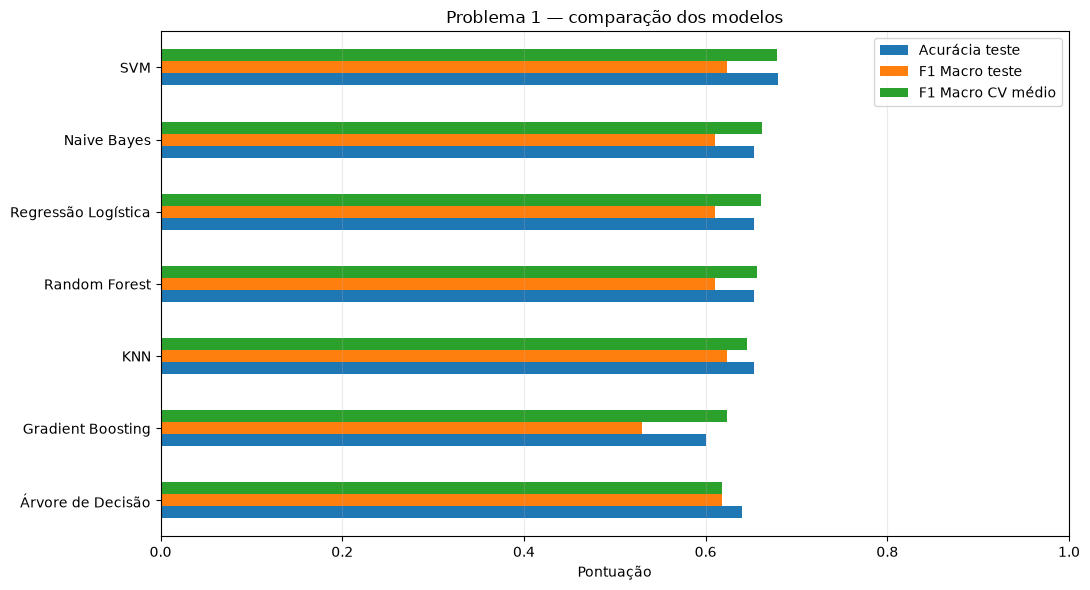

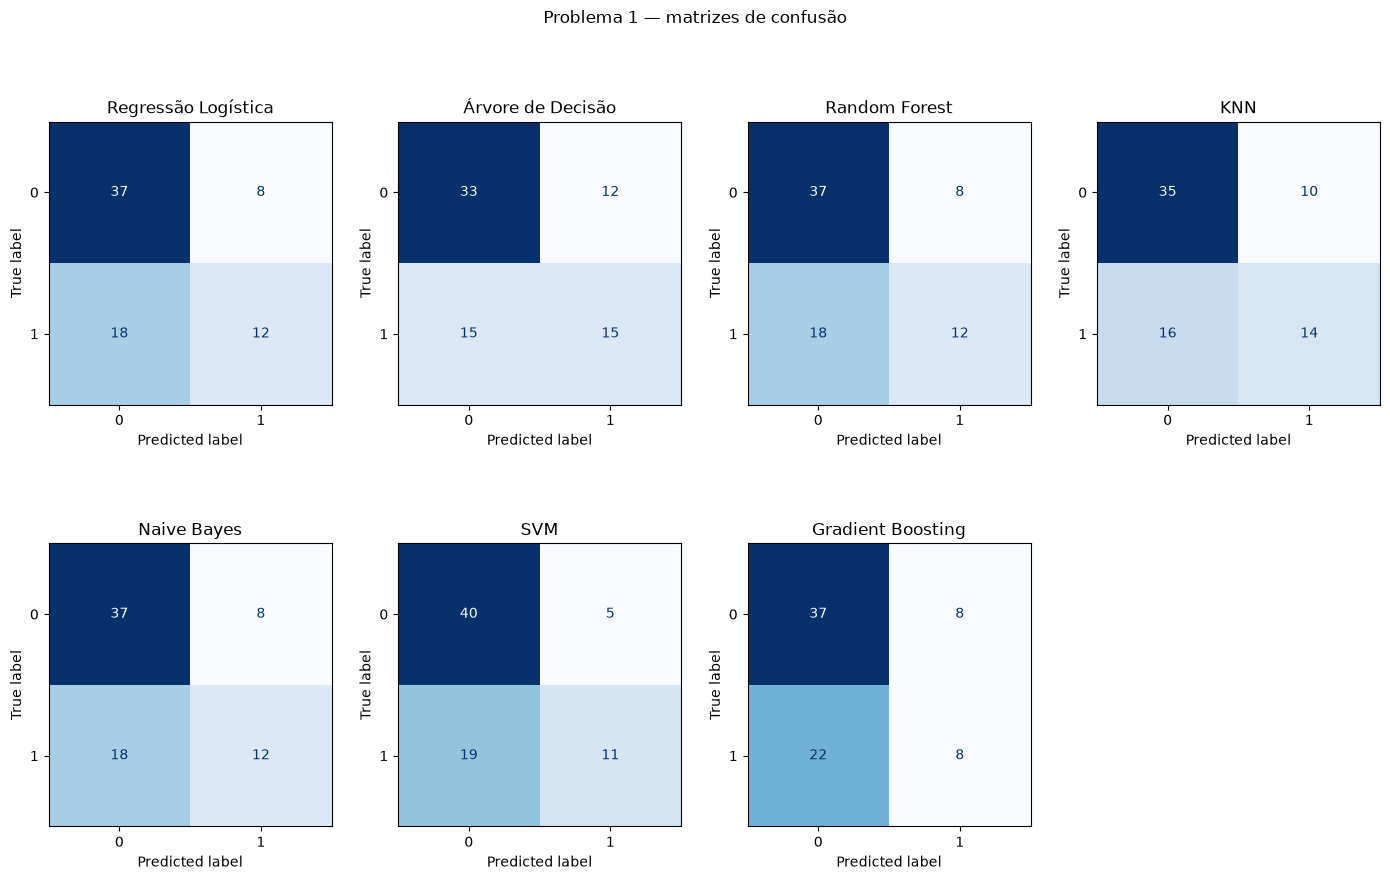

In [13]:
mostrar_relatorios(relatorios_compra)

mostrar_grafico(
    titulo="Problema 1 — comparação dos modelos",
    metricas=metricas_compra,
)
mostrar_matrizes(
    titulo="Problema 1 — matrizes de confusão",
    matrizes=matrizes_compra,
)

### Leitura do problema 1

Um F1 de treino muito superior ao F1 de teste indica overfitting. Observe também os falsos negativos: são compradores que o modelo não identificou.

# Problema 2 — Risco de internação

In [14]:
conferir_dados(dados_saude, "Risco_Internacao")

Primeiras linhas:


,Idade,Pressao_Arterial,Colesterol_Total,Frequencia_Cardiaca_Max,Risco_Internacao
0,63,101,244,83,0
1,76,152,195,64,0
2,53,143,279,93,0
3,39,131,184,65,0
4,67,169,230,61,1


Valores ausentes por coluna:


,Ausentes
Idade,0
Pressao_Arterial,0
Colesterol_Total,0
Frequencia_Cardiaca_Max,0
Risco_Internacao,0


Distribuição da variável alvo:


,Quantidade
Risco_Internacao,
0,125
1,125


In [ ]:
(
    metricas_saude,
    matrizes_saude,
    relatorios_saude,
) = avaliar_modelos(
    dados=dados_saude,
    coluna_alvo="Risco_Internacao",
)

display(metricas_saude.round(3))

Registros de treino: 175
Registros de teste: 75


In [ ]:
mostrar_relatorios(relatorios_saude)

mostrar_grafico(
    titulo="Problema 2 — comparação dos modelos",
    metricas=metricas_saude,
)
mostrar_matrizes(
    titulo="Problema 2 — matrizes de confusão",
    matrizes=matrizes_saude,
)

### Leitura do problema 2

Um falso negativo representa um paciente de alto risco classificado como baixo risco. A Regressão Logística apresenta a melhor estabilidade na validação cruzada, mas ainda exige validação clínica antes de qualquer uso real.

# Conclusão

Overfitting deve ser investigado comparando treino, teste e validação cruzada, e não somente pela matriz de confusão. O problema 1 não apresentou desempenho suficiente para produção. No problema 2, a Regressão Logística é a candidata mais estável para continuar como protótipo. Consulte `02_respostas_e_conclusoes.md` para a análise completa.